In [172]:
import pandas as pd

In [173]:
df = pd.read_csv("skoob_todos_livros.csv")

In [174]:
df

,Título do Livro,Autor,Quantidade de Páginas,Tempo de Leitura,Nota Média,Leram,Lendo,Querem,Relendo,Abandonos,Resenhas,Favoritos,Avaliaram
0,Alchemised [Edição brasileira] -,SenLinYu,900 páginas,1d 6h 0m,4.5,9155.0,4786.0,46897.0,43.0,590.0,2373.0,1646.0,6826.0
1,Sorte No Amor -,Lynn Painter,256 páginas,8h 32m,3.9,10264.0,1197.0,41474.0,53.0,362.0,1887.0,450.0,6392.0
2,Querida tia -,Valérie Perrin,496 páginas,16h 32m,4.1,2917.0,720.0,18831.0,14.0,138.0,637.0,171.0,2006.0
3,MURDLE: A ESCOLA DE MISTÉRIOS - 50 enigmas de ...,G. T. Karber,240 páginas,8h 0m,4.1,223.0,174.0,3733.0,12.0,30.0,9.0,16.0,42.0
4,Férias de matar -,Tessa Bailey,288 páginas,9h 36m,3.5,3171.0,408.0,14336.0,19.0,205.0,573.0,85.0,2146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15293,A Mente e o Significado da Vida -,Pedro Paulo Monteiro,200 páginas,6h 40m,4.2,11.0,1.0,11.0,1.0,0.0,0.0,0.0,5.0
15294,Amor de Verão - Segunda Natureza & Retratos de...,Nora Roberts,476 páginas,15h 52m,3.8,1269.0,14.0,408.0,3.0,21.0,31.0,50.0,561.0
15295,Shantaram -,Gregory David Roberts,820 páginas,1d 3h 20m,4.6,602.0,94.0,1248.0,3.0,37.0,42.0,11.0,435.0
15296,Sobre História -,Eric J. Hobsbawm,336 páginas,11h 12m,4.1,489.0,105.0,678.0,4.0,23.0,17.0,19.0,260.0


In [175]:
#tira a palavra 'páginas' da string
df['Quantidade de Páginas'] = df['Quantidade de Páginas'].str.replace('páginas', '')

In [176]:
#função que converte o tempo para Minutos
def conversorTempo(celula):

  num = ''
  tempo = 0


  for char in str(celula):
    if char.isdigit():
      num += char
    else:
      if char == 'd':
        tempo += int(num) * 1440
      elif char == 'h':
        tempo += int(num) * 60
      elif char == 'm':
        tempo += int(num)
      num = ''

  return tempo


In [177]:
#aplica a função e troca o nome
df['Tempo de Leitura'] = df['Tempo de Leitura'].apply(conversorTempo)
df.rename(columns={'Tempo de Leitura': 'Tempo de Leitura (Minutos)'}, inplace=True)

In [178]:
#tira os valores vazios
df[df['Título do Livro'].isna()]

df = df.dropna().reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15282 entries, 0 to 15281
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Título do Livro             15282 non-null  str    
 1   Autor                       15282 non-null  str    
 2   Quantidade de Páginas       15282 non-null  str    
 3   Tempo de Leitura (Minutos)  15282 non-null  int64  
 4   Nota Média                  15282 non-null  float64
 5   Leram                       15282 non-null  float64
 6   Lendo                       15282 non-null  float64
 7   Querem                      15282 non-null  float64
 8   Relendo                     15282 non-null  float64
 9   Abandonos                   15282 non-null  float64
 10  Resenhas                    15282 non-null  float64
 11  Favoritos                   15282 non-null  float64
 12  Avaliaram                   15282 non-null  float64
dtypes: float64(9), int64(1), str(3)
memory usa

In [179]:
#passa a coluna pra int
df['Quantidade de Páginas'] = df['Quantidade de Páginas'].astype(int)

In [180]:
#tira os hífens do final do nome
df['Título do Livro'] = df['Título do Livro'].str.rstrip('-')

In [181]:
df

,Título do Livro,Autor,Quantidade de Páginas,Tempo de Leitura (Minutos),Nota Média,Leram,Lendo,Querem,Relendo,Abandonos,Resenhas,Favoritos,Avaliaram
0,Alchemised [Edição brasileira],SenLinYu,900,1800,4.5,9155.0,4786.0,46897.0,43.0,590.0,2373.0,1646.0,6826.0
1,Sorte No Amor,Lynn Painter,256,512,3.9,10264.0,1197.0,41474.0,53.0,362.0,1887.0,450.0,6392.0
2,Querida tia,Valérie Perrin,496,992,4.1,2917.0,720.0,18831.0,14.0,138.0,637.0,171.0,2006.0
3,MURDLE: A ESCOLA DE MISTÉRIOS - 50 enigmas de ...,G. T. Karber,240,480,4.1,223.0,174.0,3733.0,12.0,30.0,9.0,16.0,42.0
4,Férias de matar,Tessa Bailey,288,576,3.5,3171.0,408.0,14336.0,19.0,205.0,573.0,85.0,2146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15277,A Mente e o Significado da Vida,Pedro Paulo Monteiro,200,400,4.2,11.0,1.0,11.0,1.0,0.0,0.0,0.0,5.0
15278,Amor de Verão - Segunda Natureza & Retratos de...,Nora Roberts,476,952,3.8,1269.0,14.0,408.0,3.0,21.0,31.0,50.0,561.0
15279,Shantaram,Gregory David Roberts,820,1640,4.6,602.0,94.0,1248.0,3.0,37.0,42.0,11.0,435.0
15280,Sobre História,Eric J. Hobsbawm,336,672,4.1,489.0,105.0,678.0,4.0,23.0,17.0,19.0,260.0


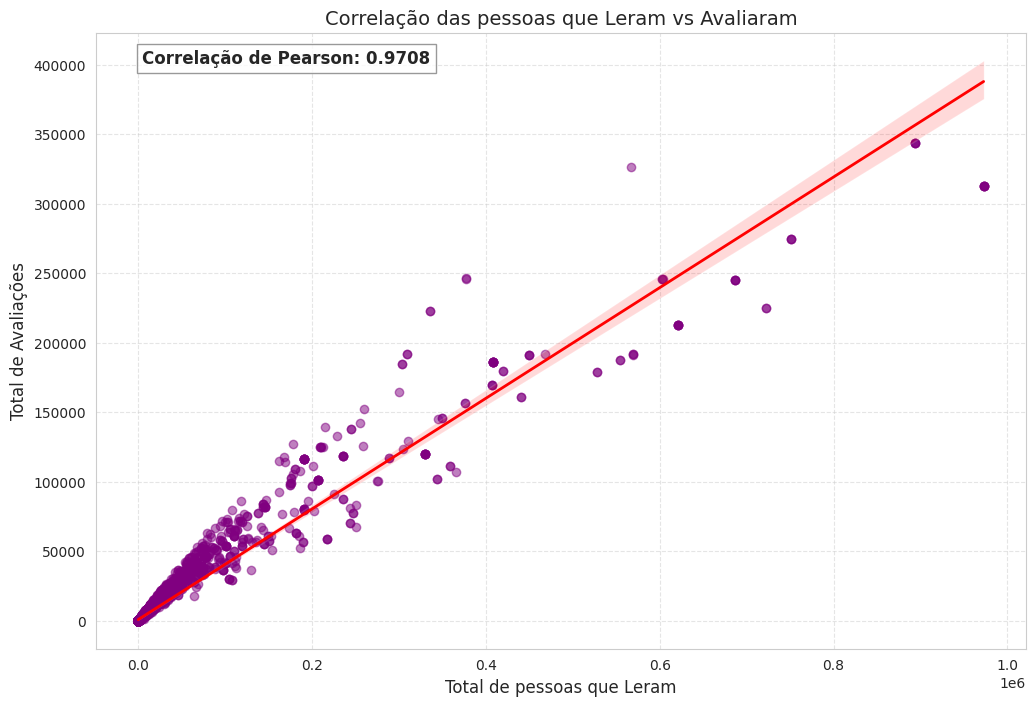

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
ax = sns.regplot(
    data=df, 
    x='Leram', 
    y='Avaliaram', 
    scatter_kws={'alpha':0.5, 'color':'purple'}, 
    line_kws={'color':'red', 'lw':2}
)

corr = df['Leram'].corr(df['Avaliaram'])

ax.text(0.05, 0.95, f'Correlação de Pearson: {corr:.4f}', 
        transform=ax.transAxes, fontsize=12, fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('Correlação das pessoas que Leram vs Avaliaram', fontsize=14)
plt.xlabel('Total de pessoas que Leram', fontsize=12)
plt.ylabel('Total de Avaliações', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

/tmp/ipykernel_32558/1168025453.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Total de livros outliers: 2421


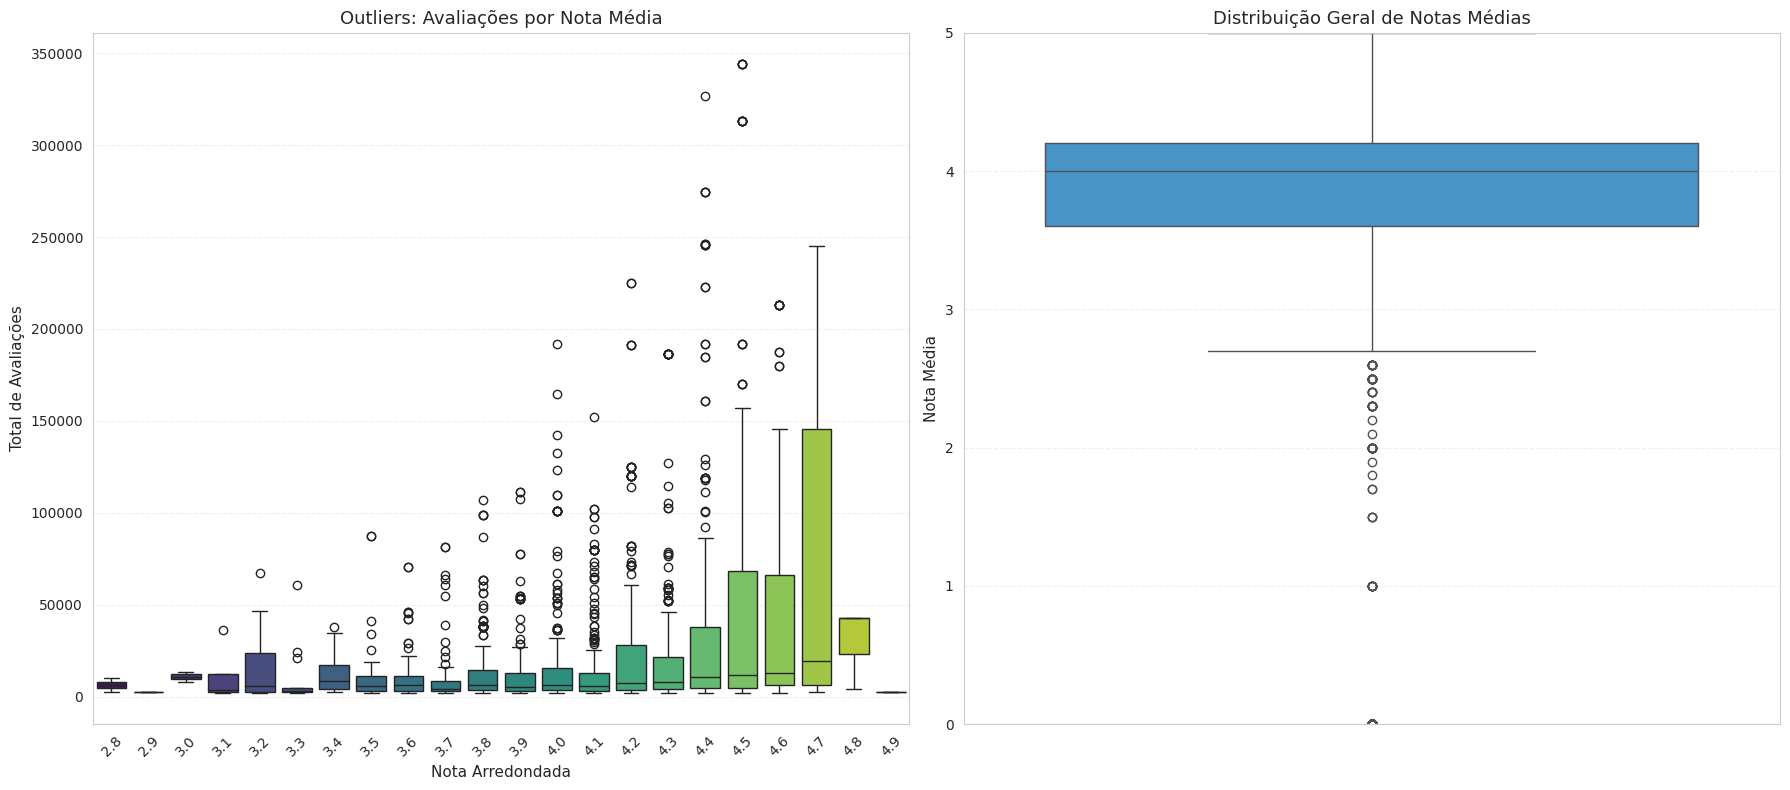

In [183]:
#definicao quartis
Q1 = df['Avaliaram'].quantile(0.25)
Q3 = df['Avaliaram'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

df_outliers = df[df['Avaliaram'] > limite_superior].copy()
df_outliers['Nota_Arredondada'] = df_outliers['Nota Média'].round(1)

#colocando os plots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

#grafico 1
sns.boxplot(
    data=df_outliers, 
    x='Nota_Arredondada', 
    y='Avaliaram',
    palette='viridis',
    ax=ax1
)
ax1.set_title('Outliers: Avaliações por Nota Média', fontsize=13)
ax1.set_xlabel('Nota Arredondada', fontsize=11)
ax1.set_ylabel('Total de Avaliações', fontsize=11)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

sns.boxplot(
    y=df['Nota Média'], 
    color='#3498db', 
    ax=ax2
)
ax2.set_ylim(0, 5) # Limita o eixo das notas de 0 a 5
ax2.set_title('Distribuição Geral de Notas Médias', fontsize=13)
ax2.set_ylabel('Nota Média', fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
print(f"Total de livros outliers: {len(df_outliers)}")
plt.show()

In [185]:
# filtra os outliers e seleciona o principal de cada nota
print(df[df['Avaliaram'] > (df['Avaliaram'].quantile(0.75) + 1.5 * (df['Avaliaram'].quantile(0.75) - df['Avaliaram'].quantile(0.25)))].assign(Nota_Arredondada=df['Nota Média'].round(1)).sort_values('Avaliaram', ascending=False).groupby('Nota_Arredondada').head(1)[['Nota_Arredondada', 'Título do Livro', 'Avaliaram', 'Leram']].sort_values(['Nota_Arredondada', 'Avaliaram'], ascending=[False, False]).to_string(index=False))


 Nota_Arredondada                                                                                              Título do Livro  Avaliaram    Leram
              4.9                                             Palavras de Radiância (Os Relatos da Guerra das Tempestades #2)      2758.0   3370.0
              4.8                                                                         Reino de Cinzas (Trono de Vidro #8)     42633.0  66357.0
              4.7                           Harry Potter e o Prisioneiro de Azkaban (Harry Potter #3) - Edição de Colecionador   245071.0 686666.0
              4.6                                   Harry Potter e o Cálice De Fogo (Harry Potter #4) - Edição de Colecionador   212786.0 621560.0
              4.5 Harry Potter e a Pedra Filosofal (Harry Potter #1) - Edição comemorativa dos 20 anos da Coleção Harry Potter   343910.0 893380.0
              4.4                                                                    É assim que acaba (É Assim Que Ac

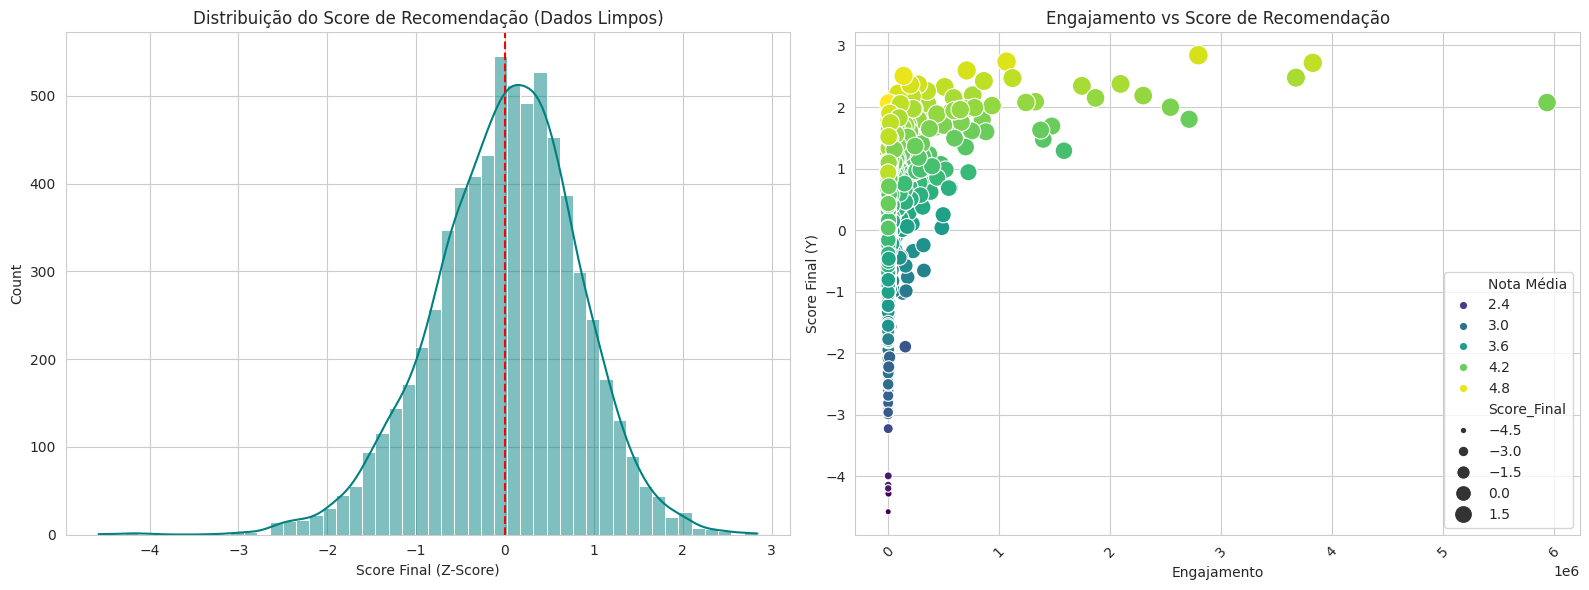


--- TOP 10 RECOMENDAÇÕES ---
                                                                                                 Título do Livro  Nota Média  Engajamento  Score_Final
                                                      Harry Potter e o Prisioneiro de Azkaban (Edição Minalima)     4.700000    2795861.0     2.842316
Harry Potter e as Relíquias da Morte (Harry Potter #7) - Edição comemorativa dos 20 anos da Coleção Harry Potter    4.733333    1067458.0     2.737165
                               Harry Potter e o Cálice de Fogo (Harry Potter #4) - Edição das Casas - Grifinória    4.612500    3826512.0     2.717857
                                                          O último olimpiano (Percy Jackson e os Olimpianos #5)     4.700000     707837.0     2.593803
                                                                            Reino de Cinzas (Trono de Vidro #8)     4.800000     139039.0     2.506500
                                            Harry Potter e a Ped

In [187]:
import numpy as np
import re
from scipy.stats import zscore

#retira notas mal calculadas
df_valid = df[df['Nota Média'] <= 5].copy()

#regex para limpar volumes de séries e edições
def limpar_titulo_raiz(nome):
    if not isinstance(nome, str): return ""
    return re.split(r'[#\(\[\-\:]', nome)[0].lower().strip()

df_valid['Titulo_Original'] = df_valid['Título do Livro'].apply(limpar_titulo_raiz)

#Agrupar por Título e somar o Engajamento
df_clean = df_valid.groupby('Titulo_Original').agg({
    'Título do Livro': 'first',
    'Nota Média': 'mean',
    'Leram': 'sum',
    'Lendo': 'sum',
    'Avaliaram': 'sum'
}).reset_index(drop=True)

df_clean['Engajamento'] = df_clean['Leram'] + df_clean['Lendo']

#Mediana de Engajamento para evitar livros desconhecidos
df_final = df_clean[df_clean['Engajamento'] >= df_clean['Engajamento'].median()].copy()


#calculo do zscore com log

#Normaliza satisfação e popularidade real
df_final['z_nota'] = zscore(df_final['Nota Média'])
df_final['z_eng'] = zscore(np.log1p(df_final['Engajamento']))

#score de recomendação: 70% Nota e 30% Popularidade Real
df_final['Score_Final'] = (df_final['z_nota'] * 0.7) + (df_final['z_eng'] * 0.3)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1 histograma
sns.histplot(df_final['Score_Final'], kde=True, color='teal', bins=50, ax=ax1)
ax1.set_title('Distribuição do Score de Recomendação (Dados Limpos)')
ax1.set_xlabel('Score Final (Z-Score)')
ax1.axvline(0, color='red', linestyle='--')

# Gráfico 2 dispersão
sns.scatterplot(data=df_final, x='Engajamento', y='Score_Final', 
                hue='Nota Média', size='Score_Final', palette='viridis', sizes=(20, 200), ax=ax2)
ax2.set_title('Engajamento vs Score de Recomendação')
ax2.set_ylabel('Score Final (Y)')

# Garantir que os labels do eixo X não sobreponham
plt.sca(ax2)
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()


#Ranking
print("\n--- TOP 10 RECOMENDAÇÕES ---")
print(df_final.sort_values('Score_Final', ascending=False)[['Título do Livro', 'Nota Média', 'Engajamento', 'Score_Final']].head(10).to_string(index=False))